In [2]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from skimage.filters import gabor, threshold_otsu
from skimage.color import rgb2hsv, rgb2lab, rgb2gray
from skimage.measure import shannon_entropy
from skimage.measure import regionprops, label as sk_label
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist
import pandas as pd
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

FOLDER_PATH = "abstrait-v4"
TARGET_SIZE = 1800

# Chargement des données

In [3]:
def pad_image_symmetric(img_path, target_size=TARGET_SIZE):
    
    img = cv2.imread(img_path)
    
    if img is None:
        raise ValueError(f"Impossible de charger l'image : {img_path}")
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img.shape[:2]
    max_dim = max(h, w)
    
    if max_dim != target_size:
        print(f"{img_path} ({w}x{h})")
        scale = target_size / max_dim
        new_w = int(w * scale)
        new_h = int(h * scale)
        
        interpolation = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC
        img = cv2.resize(img, (new_w, new_h), interpolation=interpolation)
        
        h, w = img.shape[:2]
        
    delta_w = target_size - w
    delta_h = target_size - h
    
    top = delta_h // 2
    bottom = delta_h - top
    left = delta_w // 2
    right = delta_w - left
    
    padded_img = cv2.copyMakeBorder(
        img, 
        top, bottom, left, right, 
        cv2.BORDER_REFLECT
    )
    
    return padded_img

Pré-traitement du dataset (attention, cela prend 1 minute environ)

In [3]:
images = [(img, pad_image_symmetric(os.path.join(FOLDER_PATH, img), TARGET_SIZE)) for img in os.listdir(FOLDER_PATH) if img.lower().endswith(('.jpg', '.jpeg'))]

abstrait-v4/soulages_18.jpg (1920x1080)
abstrait-v4/tyson_1.jpg (3160x3178)
abstrait-v4/siqueiros_1.jpg (1008x1200)
abstrait-v4/conner_2.jpg (1818x2343)
abstrait-v4/conner_1.jpg (2036x2763)
abstrait-v4/leslie_1.jpg (4119x2212)
abstrait-v4/kerouac_1.jpg (2871x1873)
abstrait-v4/dubuffet_9.jpg (1798x890)
abstrait-v4/herbin_6.jpg (800x746)
abstrait-v4/delaunay-r_9.jpg (991x1668)
abstrait-v4/soulages_16.jpg (1920x1080)
abstrait-v4/redon_3.jpg (1200x930)
abstrait-v4/schonberg_1.jpg (1200x883)
abstrait-v4/redon_2.jpg (1200x902)
abstrait-v4/schonberg_2.jpg (1200x1020)
abstrait-v4/schonberg_3.jpg (1200x1034)


Affichage de quelques images après traitement pour vérifier que tout fonctionne correctement

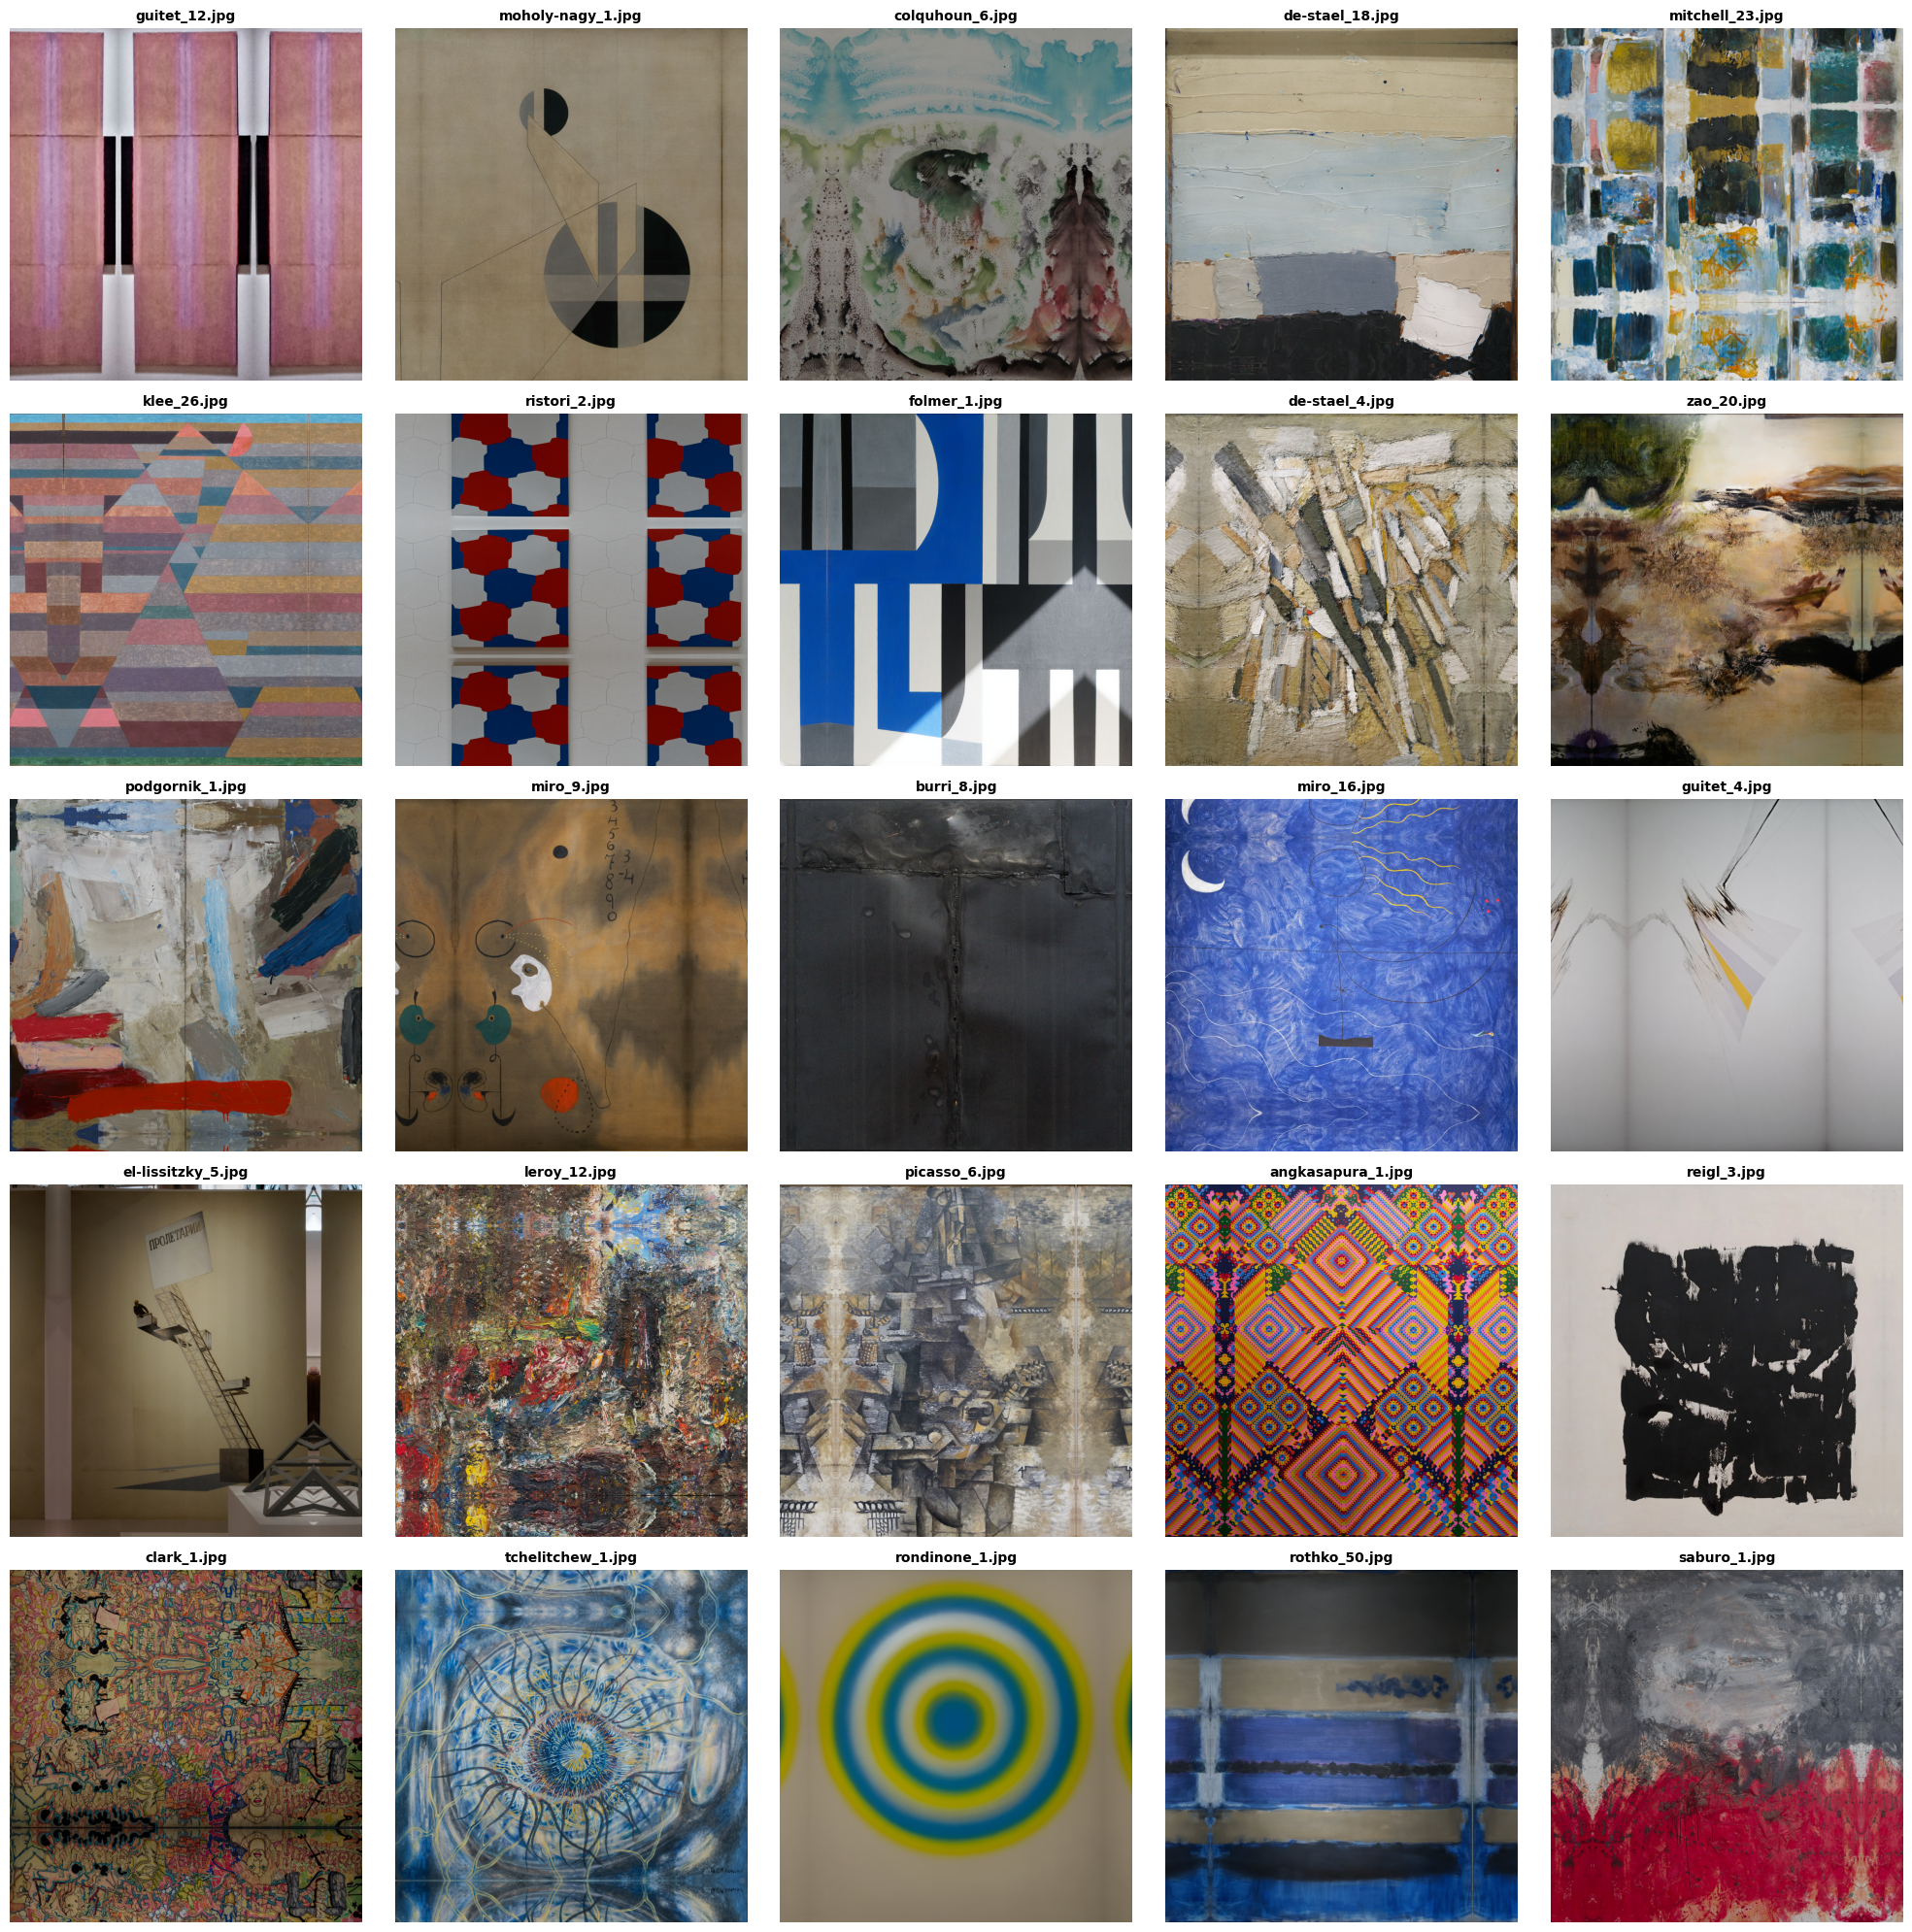

In [4]:
selected_img = random.sample(images, min(25, len(images)))

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes_flat = axes.flatten()
    
for i, (img_name, img) in enumerate(selected_img):
    ax = axes_flat[i]
    
    ax.imshow(img)
    
    ax.set_title(img_name, fontsize=10, fontweight='bold')
    ax.axis('off')
        
plt.tight_layout()
plt.show()

# Feature extraction

In [5]:
def extract_color_features(img):
    feats = {}
    h, w = img.shape[:2]

    hsv = rgb2hsv(img)
    for i, c in enumerate(['h','s','v']):
        hist, _ = np.histogram(hsv[:,:,i], bins=32, range=(0,1))
        hist = hist / hist.sum()
        feats[f'hist_{c}'] = hist

    lab = rgb2lab(img)
    for i, c in enumerate(['L','a','b']):
        ch = lab[:,:,i].ravel()
        feats[f'{c}_moy']  = np.mean(ch)
        feats[f'{c}_std']  = np.std(ch)
        feats[f'{c}_skew'] = stats.skew(ch)
        feats[f'{c}_kurt'] = stats.kurtosis(ch)

    # palette dominante avec kmeans (5 couleurs)
    pix = img.reshape(-1,3).astype(np.float32)/255
    if len(pix) > 5000:
        idx = np.random.choice(len(pix), 5000, replace=False)
        pix_sample = pix[idx]
    else:
        pix_sample = pix
    km = KMeans(n_clusters=5, n_init=3, random_state=0).fit(pix_sample)
    feats['palette'] = km.cluster_centers_
    feats['palette_prop'] = np.bincount(km.labels_, minlength=5) / len(km.labels_)

    # grille 4x4 de luminosité, sert pour la composition
    L = lab[:,:,0]
    grid = np.zeros((4,4))
    ch_h, ch_w = h//4, w//4
    for i in range(4):
        for j in range(4):
            grid[i,j] = L[i*ch_h:(i+1)*ch_h, j*ch_w:(j+1)*ch_w].mean()
    feats['grid_lum'] = grid.flatten()

    return feats


def extract_texture_features(gray):
    feats = {}

    # GLCM classique, on prend plusieurs angles pour pas privilegier une direction
    glcm = graycomatrix(gray, distances=[1,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    for p in ['contrast','dissimilarity','homogeneity','energy','correlation']:
        feats[f'glcm_{p}'] = graycoprops(glcm, p).ravel()

    # LBP a 3 echelles differentes
    for r in [1,2,4]:
        npts = 8*r
        lbp = local_binary_pattern(gray, npts, r, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=npts+2, range=(0,npts+2), density=True)
        feats[f'lbp{r}'] = hist

    # gabor : 4 angles x 3 frequences = 12 filtres
    means, stds = [], []
    img_f = gray.astype(np.float32)/255
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        for freq in [0.1, 0.25, 0.4]:
            real, _ = gabor(img_f, frequency=freq, theta=theta)
            means.append(np.mean(np.abs(real)))
            stds.append(np.std(np.abs(real)))
    feats['gabor_means'] = np.array(means)
    feats['gabor_stds']  = np.array(stds)

    return feats


def extract_geometry_features(gray_f, gray):
    feats = {}
    h, w = gray_f.shape

    # spectre de puissance pour voir la pente (image naturelle = pente -2 environ)
    f = np.fft.fft2(gray_f)
    fshift = np.fft.fftshift(f)
    power = np.abs(fshift)**2 + 1e-10

    cy, cx = h//2, w//2
    Y, X = np.ogrid[:h,:w]
    R = np.sqrt((X-cx)**2 + (Y-cy)**2).astype(int)
    rmax = min(cy,cx)

    radial = []
    for r in range(1, rmax):
        radial.append(power[R==r].mean())
    radial = np.array(radial)

    slope, _, _, _, _ = stats.linregress(np.log(np.arange(1,rmax)), np.log(radial))
    feats['fft_slope'] = slope
    feats['fft_ratio'] = radial[rmax//2:].mean() / (radial[:rmax//2].mean()+1e-10)

    feats['entropy'] = shannon_entropy(gray)

    # entropie locale sur patches 64x64
    ent_locales = []
    for i in range(0, h-64, 64):
        for j in range(0, w-64, 64):
            ent_locales.append(shannon_entropy(gray[i:i+64, j:j+64]))
    feats['entropy_loc_moy'] = np.mean(ent_locales)
    feats['entropy_loc_std'] = np.std(ent_locales)

    gx = cv2.Sobel(gray_f, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_f, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    orient = np.arctan2(gy, gx)

    feats['grad_moy'] = np.mean(mag)
    feats['grad_std'] = np.std(mag)

    hist_o, _ = np.histogram(orient.ravel(), bins=8, range=(-np.pi,np.pi), density=True)
    feats['orient_hist'] = hist_o

    # HOG sur image reduite sinon trop long
    small = cv2.resize(gray, (128,128))
    feats['hog'] = hog(small, orientations=8, pixels_per_cell=(16,16), cells_per_block=(2,2))

    # structure tensor pour la coherence directionnelle
    Ixx, Iyy, Ixy = gx*gx, gy*gy, gx*gy
    s = 3
    Jxx = cv2.GaussianBlur(Ixx, (0,0), s)
    Jyy = cv2.GaussianBlur(Iyy, (0,0), s)
    Jxy = cv2.GaussianBlur(Ixy, (0,0), s)
    trace = Jxx+Jyy
    det = Jxx*Jyy - Jxy**2
    disc = np.sqrt(np.maximum(trace**2/4 - det, 0))
    l1, l2 = trace/2+disc, trace/2-disc
    coh = ((l1-l2)/(l1+l2+1e-10))**2
    feats['coherence_moy'] = np.mean(coh)
    feats['coherence_std'] = np.std(coh)

    # dimension fractale par box counting
    sizes, counts = [], []
    edges = cv2.Canny(gray, 50, 150) > 0
    for size in [2,4,8,16,32,64]:
        hb, wb = edges.shape[0]//size, edges.shape[1]//size
        if hb==0 or wb==0:
            continue
        crop = edges[:hb*size, :wb*size]
        blocks = crop.reshape(hb, size, wb, size)
        cnt = (blocks.sum(axis=(1,3)) > 0).sum()
        sizes.append(size)
        counts.append(cnt)
    if len(sizes) >= 2:
        coef = np.polyfit(np.log(sizes), np.log(counts), 1)
        feats['fractal_dim'] = -coef[0]
    else:
        feats['fractal_dim'] = 0.0

    return feats


def extract_file_features(img_name, folder=FOLDER_PATH):
    feats = {}
    path = os.path.join(folder, img_name)
    taille = os.path.getsize(path)

    img_orig = cv2.imread(path)
    h, w = img_orig.shape[:2]

    feats['taille_octets'] = taille
    feats['taille_par_pixel'] = taille / (h*w)
    feats['taille_log'] = np.log1p(taille)
    feats['aspect_ratio'] = h / (w + 1e-10)

    return feats


def extract_symmetry_from_grid(grid_flat):
    feats = {}
    G = grid_flat.reshape(4,4)

    # gauche/droite
    diff_lr = np.mean(np.abs(G - np.fliplr(G)))
    feats['sym_lr'] = 1 - diff_lr / (np.mean(np.abs(G))+1e-10)

    # haut/bas
    diff_tb = np.mean(np.abs(G - np.flipud(G)))
    feats['sym_tb'] = 1 - diff_tb / (np.mean(np.abs(G))+1e-10)

    # diagonale
    diff_d = np.mean(np.abs(G - G.T))
    feats['sym_diag'] = 1 - diff_d / (np.mean(np.abs(G))+1e-10)

    centre = G[1:3,1:3].mean()
    bord = np.concatenate([G[0,:], G[3,:], G[1:3,0], G[1:3,3]]).mean()
    feats['centre_vs_bord'] = centre - bord

    feats['var_lignes'] = G.mean(axis=1).var()
    feats['var_colonnes'] = G.mean(axis=0).var()

    gx, gy = np.gradient(G, axis=1), np.gradient(G, axis=0)
    feats['grad_h'] = np.abs(gx).mean()
    feats['grad_v'] = np.abs(gy).mean()

    return feats


def deriche(gray_f, sigma=3.0):
    smooth = gaussian_filter(gray_f, sigma=sigma)
    gx = cv2.Sobel(smooth.astype(np.float32), cv2.CV_64F, 1, 0, ksize=5)
    gy = cv2.Sobel(smooth.astype(np.float32), cv2.CV_64F, 0, 1, ksize=5)
    mag = np.sqrt(gx**2+gy**2)
    return mag, gx, gy


def extract_deriche_features(gray_f, perc=85):
    feats = {}

    for sigma in [2.0, 5.0]:
        mag, gx, gy = deriche(gray_f, sigma)
        seuil = np.percentile(mag, perc)
        fort = mag > seuil

        mag_fort = mag[fort]
        if len(mag_fort)==0:
            mag_fort = np.array([0.])

        s_str = f"{int(sigma)}"
        feats[f'deriche{s_str}_densite'] = fort.mean()
        feats[f'deriche{s_str}_mag_moy']  = mag_fort.mean()
        feats[f'deriche{s_str}_mag_std']  = mag_fort.std()

        orient = np.arctan2(gy[fort], gx[fort])
        hist_o, _ = np.histogram(orient, bins=8, range=(-np.pi,np.pi), density=True)
        feats[f'deriche{s_str}_orient'] = hist_o

        lab_e = sk_label(fort.astype(np.uint8))
        props = regionprops(lab_e)
        if len(props) > 0:
            per = np.array([p.perimeter for p in props]) / max(gray_f.shape)
            feats[f'deriche{s_str}_n_contours'] = len(per)
            feats[f'deriche{s_str}_contour_moy'] = per.mean()
            feats[f'deriche{s_str}_contour_max'] = per.max()
            seuil_court = np.percentile(per, 75)
            feats[f'deriche{s_str}_ratio_courts'] = (per < seuil_court).mean()
        else:
            feats[f'deriche{s_str}_n_contours'] = 0.
            feats[f'deriche{s_str}_contour_moy'] = 0.
            feats[f'deriche{s_str}_contour_max'] = 0.
            feats[f'deriche{s_str}_ratio_courts'] = 0.

    return feats


def extract_repetition_features(gray_f):
    feats = {}
    h, w = gray_f.shape

    # autocorrelation, sert a detecter les motifs repetitifs (Vasarely, Hantai...)
    small = cv2.resize(gray_f, (64,64))
    small_c = small - small.mean()
    fft_ac = np.fft.fft2(small_c)
    ac = np.fft.ifft2(fft_ac * np.conj(fft_ac)).real
    ac = ac / (ac[0,0]+1e-10)
    ac_shift = np.fft.fftshift(ac)

    cy2, cx2 = ac_shift.shape[0]//2, ac_shift.shape[1]//2
    mask = np.ones_like(ac_shift, dtype=bool)
    Y, X = np.ogrid[:ac_shift.shape[0], :ac_shift.shape[1]]
    mask[(Y-cy2)**2+(X-cx2)**2 < 25] = False

    ac_out = ac_shift[mask]
    feats['autocorr_max'] = ac_out.max()
    feats['autocorr_moy'] = ac_out.mean()
    feats['autocorr_std'] = ac_out.std()

    f = np.fft.fft2(gray_f)
    fshift = np.fft.fftshift(f)
    power = np.log(np.abs(fshift)**2 + 1)

    cy, cx = h//2, w//2
    Y2, X2 = np.ogrid[:h,:w]
    mask_dc = (Y2-cy)**2+(X2-cx)**2 > 100

    power_masked = power[mask_dc]
    seuil = np.percentile(power_masked, 95)
    feats['fft_peak_ratio'] = (power_masked > seuil).sum() / (len(power_masked)+1e-10)
    feats['fft_peak_max'] = power_masked.max()

    # frequence dominante hors composante continue
    p2 = np.abs(fshift)**2
    p2[~mask_dc] = 0
    peak = np.unravel_index(p2.argmax(), p2.shape)
    dist = np.sqrt((peak[0]-cy)**2 + (peak[1]-cx)**2)
    feats['freq_dominante'] = dist / max(h,w)

    return feats


def extract_geometric_features(gray, gray_f):
    feats = {}
    h, w = gray.shape

    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50,
                            minLineLength=w//8, maxLineGap=10)

    if lines is not None:
        n = len(lines)
        longueurs, angles = [], []
        for x1,y1,x2,y2 in lines[:,0]:
            longueurs.append(np.sqrt((x2-x1)**2+(y2-y1)**2))
            angles.append(np.degrees(np.arctan2(y2-y1, x2-x1)) % 180)

        feats['hough_n'] = n
        feats['hough_long_moy'] = np.mean(longueurs)
        feats['hough_long_max'] = np.max(longueurs)

        n_hv = 0
        for a in angles:
            if a < 10 or a > 170 or 80 < a < 100:
                n_hv += 1
        feats['hough_ratio_hv'] = n_hv / (n+1e-10)

        hist_a, _ = np.histogram(angles, bins=18, range=(0,180), density=True)
        hist_a = (hist_a+1e-10) / (hist_a+1e-10).sum()
        feats['hough_entropy'] = shannon_entropy(hist_a)
    else:
        feats['hough_n'] = 0.
        feats['hough_long_moy'] = 0.
        feats['hough_long_max'] = 0.
        feats['hough_ratio_hv'] = 0.
        feats['hough_entropy'] = 0.

    # compacite et rectangularite des regions (Otsu)
    try:
        seuil = threshold_otsu(gray)
        binaire = gray > seuil
        lab_r = sk_label(binaire)
        props = regionprops(lab_r)

        compacite, rectangularite = [], []
        for p in props:
            if p.perimeter > 0 and p.area > 50:
                c = 4*np.pi*p.area / (p.perimeter**2)
                compacite.append(min(c,1.0))
                bb = (p.bbox[2]-p.bbox[0]) * (p.bbox[3]-p.bbox[1])
                if bb > 0:
                    rectangularite.append(p.area/bb)

        feats['compacite_moy'] = np.mean(compacite) if compacite else 0.
        feats['rect_moy'] = np.mean(rectangularite) if rectangularite else 0.
        feats['rect_std'] = np.std(rectangularite) if rectangularite else 0.
    except:
        feats['compacite_moy'] = 0.
        feats['rect_moy'] = 0.
        feats['rect_std'] = 0.

    return feats


def extract_richness_features(img, gray):
    feats = {}
    
    feats['entropy'] = shannon_entropy(gray)
    
    # entropie par canal, on voit si une couleur domine plus que les autres
    feats['entropy_r'] = shannon_entropy(img[:,:,0])
    feats['entropy_g'] = shannon_entropy(img[:,:,1])
    feats['entropy_b'] = shannon_entropy(img[:,:,2])
    
    hsv = rgb2hsv(img)
    sat = (hsv[:,:,1]*255).astype(np.uint8)
    feats['entropy_sat'] = shannon_entropy(sat)
    
    # combien de couleurs differentes (avec quantization sinon on a 16M de couleurs)
    quant = img // 8
    nb_couleurs = len(np.unique(quant.reshape(-1,3), axis=0))
    feats['nb_couleurs'] = nb_couleurs
    
    h, w = gray.shape
    stds = []
    for i in range(0, h-16, 16):
        for j in range(0, w-16, 16):
            patch = gray[i:i+16, j:j+16]
            stds.append(patch.std())
    
    feats['std_local_moy'] = np.mean(stds)
    feats['std_local_std'] = np.std(stds)
    feats['std_local_min'] = np.min(stds)
    
    # zones plates = std faible, ca permet de detecter les toiles minimalistes
    nb_plat = 0
    for s in stds:
        if s < 5:
            nb_plat += 1
    feats['ratio_plat'] = nb_plat / len(stds)
    
    return feats


def extract_expert_features(img_name, img_gray_float):

    features = {}

    path = os.path.join(FOLDER_PATH, img_name)

    taille_octets = os.path.getsize(path)

    h, w = img_gray_float.shape
    
    # complexité/détail
    ratio_compression = taille_octets / (h * w)

    grille_4x4 = cv2.resize(img_gray_float, (4, 4), interpolation=cv2.INTER_AREA).astype(float)
    symetrie = (np.mean(np.abs(grille_4x4[:, 0] - grille_4x4[:, 3]))
                + np.mean(np.abs(grille_4x4[:, 1] - grille_4x4[:, 2])))

    # TF (motifs répétitifs)
    img_small = cv2.resize(img_gray_float, (256, 256))
    f = np.fft.fft2(img_small)
    fshift = np.fft.fftshift(f)
    magnitude = 20 * np.log(np.abs(fshift) + 1)
    
    # masquage des basses fréquences au centre (pour ne garder que les vrais motifs)
    magnitude[128-10:128+10, 128-10:128+10] = 0
    
    seuil_pics = np.mean(magnitude) + 3 * np.std(magnitude)
    nb_pics_fft = np.sum(magnitude > seuil_pics)

    features['ratio_compression'] = ratio_compression
    features['symetrie'] = symetrie
    features['nb_pics_fft'] = nb_pics_fft

    return features

In [6]:
def extract_all_features(img_name, img):
    feats = {}

    small = cv2.resize(img, (256,256))
    gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)
    gray_f = gray.astype(np.float32) / 255

    feats.update(extract_color_features(small))
    feats.update(extract_texture_features(gray))
    feats.update(extract_geometry_features(gray_f, gray))
    feats.update(extract_file_features(img_name))
    feats.update(extract_symmetry_from_grid(feats['grid_lum']))
    feats.update(extract_deriche_features(gray_f))
    feats.update(extract_richness_features(small, gray))
    feats.update(extract_repetition_features(gray_f))
    feats.update(extract_geometric_features(gray, gray_f))
    feats.update(extract_expert_features(img_name, gray_f))

    return feats


def flatten_features(feat_dict):
    vec = []
    for k, v in feat_dict.items():
        if isinstance(v, np.ndarray):
            vec.extend(v.ravel().tolist())
        else:
            vec.append(float(v))
    return np.array(vec, dtype=np.float32)

In [7]:
def count_features_dim(feats):
    def get_dim(item):
        val = item[1]
        return val.shape[0] if isinstance(val, np.ndarray) else 1

    sorted_feats = sorted(feats.items(), key=get_dim, reverse=True)

    for k, v in sorted_feats:
        if isinstance(v, np.ndarray):
            print(f"{k}: {v.shape[0]} features")
        else:
            print(f"{k}: 1 feature")

In [9]:
img_name, img = images[0]
feats = extract_all_features(img_name, img)
count_features_dim(feats)

vec = flatten_features(feats)
print(f"\nNb features (avant PCA) : {len(vec)}")

hog: 1568 features
lbp4: 34 features
hist_h: 32 features
hist_s: 32 features
hist_v: 32 features
lbp2: 18 features
grid_lum: 16 features
gabor_means: 12 features
gabor_stds: 12 features
lbp1: 10 features
glcm_contrast: 8 features
glcm_dissimilarity: 8 features
glcm_homogeneity: 8 features
glcm_energy: 8 features
glcm_correlation: 8 features
orient_hist: 8 features
deriche2_orient: 8 features
deriche5_orient: 8 features
palette: 5 features
palette_prop: 5 features
L_moy: 1 feature
L_std: 1 feature
L_skew: 1 feature
L_kurt: 1 feature
a_moy: 1 feature
a_std: 1 feature
a_skew: 1 feature
a_kurt: 1 feature
b_moy: 1 feature
b_std: 1 feature
b_skew: 1 feature
b_kurt: 1 feature
fft_slope: 1 feature
fft_ratio: 1 feature
entropy: 1 feature
entropy_loc_moy: 1 feature
entropy_loc_std: 1 feature
grad_moy: 1 feature
grad_std: 1 feature
coherence_moy: 1 feature
coherence_std: 1 feature
fractal_dim: 1 feature
taille_octets: 1 feature
taille_par_pixel: 1 feature
taille_log: 1 feature
aspect_ratio: 1 fea

Calcul des features pour toutes les images (et sauvegarde dans features_brutes.pkl, s'il n'existe pas déjà)

In [18]:
all_features = []
all_names    = []

if os.path.exists("features_brutes.pkl"):
    with open("features_brutes.pkl", "rb") as f:
        all_features, all_names = pickle.load(f)

else:
    for img_name, img in tqdm(images, desc="Extraction des features", unit="img"):
        try:
            feats = extract_all_features(img_name, img)
            vec   = flatten_features(feats)
            all_features.append(vec)
            all_names.append(img_name)
        except Exception as e:
            print(f"Erreur sur {img_name} : {e}")
    
    with open("features_brutes.pkl", "wb") as f:
        pickle.dump((all_features, all_names), f)

X = np.stack(all_features)
names = np.array(all_names)

Extraction des features: 100%|██████████| 1700/1700 [29:39<00:00,  1.05s/img]


Gestion des NaN

In [20]:
print(X.shape)

nan_cols = np.where(np.isnan(X).any(axis=0))[0]
print(f"\nFeatures avec NaN : {len(nan_cols)} => indices : {nan_cols[:10]}")

nan_rows = np.where(np.isnan(X).any(axis=1))[0]
print(f"\nImages avec NaN : {len(nan_rows)}")
for i in nan_rows[:10]:
    n_nan = np.isnan(X[i]).sum()
    print(f"[{i}] {names[i]} ({n_nan} NaN)")

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

assert not np.isnan(X).any(), "NaN restants"

(1700, 1924)

Features avec NaN : 0 => indices : []

Images avec NaN : 0


# PCA

In [21]:
N_DIMS_PER_GROUP = 32

ref_feats = extract_all_features(images[0][0], images[0][1])
group_indices = {}
cursor = 0

for k, v in ref_feats.items():
    size = np.size(np.atleast_1d(v)) 

    if any(k.startswith(p) for p in ['hsv','lab','palette','spatial','richness','file_size','aspect']):
        group = 'color_richness'
    elif any(k.startswith(p) for p in ['glcm','lbp','gabor','autocorr','fft_peak','fft_dominant','repetition']):
        group = 'texture_repetition'
    elif k == 'hog':
        group = 'hog'
    elif any(k.startswith(p) for p in ['deriche','contour','shape']):
        group = 'contours_shapes'
    elif any(k.startswith(p) for p in ['hough','geom','grid_sym','grid_center','grid_row','grid_col','grid_grad',
                                        'symmetry','structure_tensor','fractal','entropy','gradient',
                                        'fft_slope','fft_high']):
        group = 'geometry_symmetry'
    else:
        group = 'geometry_symmetry'

    if group not in group_indices:
        group_indices[group] = []
        
    group_indices[group].extend(range(cursor, cursor + size))
    cursor += size

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nDimensions par groupe :")
X_parts  = {}
for group, idx in group_indices.items():
    X_group = X_scaled[:, idx]
    n_comp = min(N_DIMS_PER_GROUP, X_group.shape[1], X_group.shape[0])
    pca_g = PCA(n_components=n_comp, random_state=42)
    X_proj = pca_g.fit_transform(X_group)
    X_parts[group] = X_proj
    var = pca_g.explained_variance_ratio_.sum() * 100
    pct_dim = len(idx) / cursor * 100
    print(f"{group:} : {len(idx)} dims ({pct_dim:4.1f}%)"
          f"=> {n_comp} PC  ({var:.0f}% var)")

X_balanced = np.hstack([X_parts[g] for g in sorted(group_indices.keys())])
print(X_balanced.shape)

with open("features.pkl", "wb") as f:
    pickle.dump((all_features, all_names), f)


Dimensions par groupe :
geometry_symmetry : 174 dims ( 9.0%)=> 32 PC  (75% var)
color_richness : 21 dims ( 1.1%)=> 21 PC  (100% var)
texture_repetition : 131 dims ( 6.8%)=> 32 PC  (98% var)
hog : 1568 dims (81.5%)=> 32 PC  (51% var)
contours_shapes : 30 dims ( 1.6%)=> 30 PC  (100% var)
(1700, 147)
